<a href="https://colab.research.google.com/github/lissettzuniga/data-science-course/blob/main/projects/telecom_x_churn_analysis/Telecom%20X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Telecom X - Customer Churn Analysis**

## Objective

Telecom X is experiencing a high rate of customer cancellations (churn).  
The objective of this project is to analyze customer data to identify patterns and factors associated with churn.

This analysis includes:

- Data extraction from an API
- Data cleaning and transformation (ETL)
- Exploratory Data Analysis (EDA)
- Data visualization
- Business insights to help reduce customer churn

#📌 Extraction

## Data Extraction

In this step, we load the Telecom X dataset directly from a public JSON file hosted on GitHub.
The data will be converted into a pandas DataFrame for further analysis.

In [1]:
import pandas as pd

In [2]:
url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

In [3]:
data = pd.read_json(url)
data.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transform

The dataset contains nested JSON structures in the columns:

- customer
- phone
- internet
- account

To make the dataset suitable for analysis, these nested fields are normalized into separate columns using `pd.json_normalize()`.

In [4]:
customer = pd.json_normalize(data['customer'])
phone = pd.json_normalize(data['phone'])
internet = pd.json_normalize(data['internet'])
account = pd.json_normalize(data['account'])

In [5]:
df = pd.concat(
    [data[['customerID','Churn']], customer, phone, internet, account],
    axis=1
)

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [6]:
df.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

## Data Cleaning

In this step, we check the dataset for potential issues that may affect the analysis.

We will verify:

- Missing values
- Duplicate records
- Incorrect data types
- Category inconsistencies

Cleaning the dataset ensures the reliability of the exploratory data analysis.

In [7]:
df.shape

(7267, 21)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [9]:
df.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,SeniorCitizen,tenure,Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


In [12]:
df['Charges.Total'].dtype

dtype('O')

In [13]:
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

In [14]:
df['Charges.Total'].dtype

dtype('float64')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [16]:
df = df.dropna()

In [17]:
df.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [18]:
df.columns = df.columns.str.replace('.', '_')

In [19]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


## Feature Engineering

To gain a more detailed view of customer spending behavior, we create a new column called **Cuentas_Diarias**.

This column represents the estimated daily cost of the service based on the monthly charges.

Cuentas_Diarias = MonthlyCharges / 30

In [20]:
df['Cuentas_Diarias'] = (df['Charges_Monthly'] / 30).round(2)

In [21]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


## Data Standardization

To improve the consistency and usability of the dataset, some variables are standardized.

The following transformations are applied:

- Converting categorical values such as "Yes" and "No" into binary values (1 and 0)
- Renaming columns to improve readability and consistency

In [22]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [23]:
df['Churn'].value_counts()

,count
Churn,
0.0,5163
1.0,1869


In [24]:
binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling']

for col in binary_cols:
    df[col] = df[col].map({'Yes':1, 'No':0})

In [25]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0.0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1.0,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1.0,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1.0,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80


#📊 Analysis

## Descriptive Data Analysis

In this step, we analyze the dataset using descriptive statistics to better understand customer behavior.

We calculate metrics such as:

- Mean
- Median
- Standard deviation
- Minimum and maximum values

These metrics help us understand the distribution of numeric variables such as tenure, monthly charges, and total charges.

In [26]:
df.describe()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges_Monthly,Charges_Total,Cuentas_Diarias
count,7032.000000,7256.0000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000
mean,0.265785,0.1629,0.483600,0.299063,32.395535,0.902839,0.593716,64.755423,2280.634213,2.158467
std,0.441782,0.3693,0.499765,0.457879,24.558067,0.296197,0.491173,30.125739,2268.632997,1.004282
min,0.000000,0.0000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,0.0000,0.000000,0.000000,9.000000,1.000000,0.000000,35.450000,400.225000,1.180000
50%,0.000000,0.0000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1391.000000,2.340000
75%,1.000000,0.0000,1.000000,1.000000,55.000000,1.000000,1.000000,89.900000,3785.300000,3.000000
max,1.000000,1.0000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


In [27]:
df[['tenure','Charges_Monthly','Charges_Total','Cuentas_Diarias']].mean()

,0
tenure,32.395535
Charges_Monthly,64.755423
Charges_Total,2280.634213
Cuentas_Diarias,2.158467


In [28]:
df[['tenure','Charges_Monthly','Charges_Total','Cuentas_Diarias']].median()

,0
tenure,29.00
Charges_Monthly,70.30
Charges_Total,1391.00
Cuentas_Diarias,2.34


In [29]:
df[['tenure','Charges_Monthly','Charges_Total','Cuentas_Diarias']].std()

,0
tenure,24.558067
Charges_Monthly,30.125739
Charges_Total,2268.632997
Cuentas_Diarias,1.004282


In [30]:
df['Churn'].value_counts()

,count
Churn,
0.0,5163
1.0,1869


In [31]:
df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
0.0,73.421502
1.0,26.578498


In [32]:
df.groupby('Churn')[['tenure','Charges_Monthly','Charges_Total','Cuentas_Diarias']].mean()

,tenure,Charges_Monthly,Charges_Total,Cuentas_Diarias
Churn,,,,
0.0,37.650010,61.307408,2555.344141,2.043486
1.0,17.979133,74.441332,1531.796094,2.481450


In [33]:
df[['tenure','Charges_Monthly','Charges_Total','Cuentas_Diarias']].describe()

,tenure,Charges_Monthly,Charges_Total,Cuentas_Diarias
count,7256.000000,7256.000000,7256.000000,7256.000000
mean,32.395535,64.755423,2280.634213,2.158467
std,24.558067,30.125739,2268.632997,1.004282
min,1.000000,18.250000,18.800000,0.610000
25%,9.000000,35.450000,400.225000,1.180000
50%,29.000000,70.300000,1391.000000,2.340000
75%,55.000000,89.900000,3785.300000,3.000000
max,72.000000,118.750000,8684.800000,3.960000


## Churn Distribution

In this step, we analyze how the **churn variable** is distributed among customers.

This helps us understand the proportion of customers who stayed with the company and those who canceled their service.

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [35]:
df['Churn'].value_counts()

,count
Churn,
0.0,5163
1.0,1869


### Insights

The churn distribution shows that most customers remain with the company, while a smaller proportion cancel their service.

Understanding this proportion is important because it helps measure the **customer retention rate** and highlights the need to identify factors associated with churn.

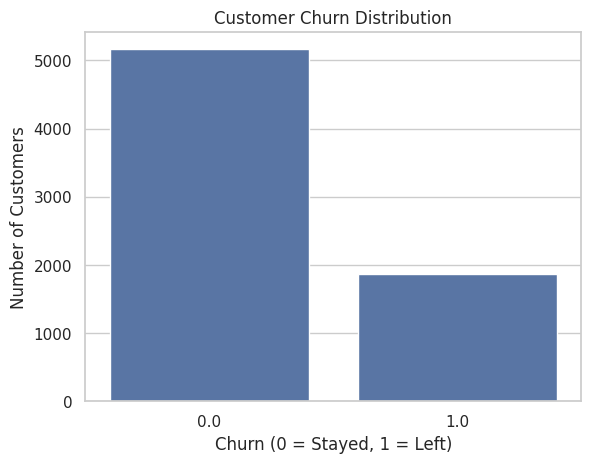

In [36]:
sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn (0 = Stayed, 1 = Left)')
plt.ylabel('Number of Customers')

plt.show()

In [37]:
df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
0.0,73.421502
1.0,26.578498


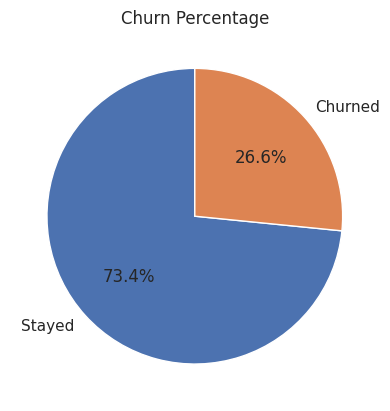

In [38]:
df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Stayed','Churned'],
    startangle=90
)

plt.title('Churn Percentage')
plt.ylabel('')
plt.show()

## Churn Analysis by Categorical Variables

In this step, we explore how customer churn varies across different categorical variables such as:

- Gender
- Contract type
- Payment method
- Internet service

Analyzing churn across these categories helps identify patterns that may explain why customers leave the service.

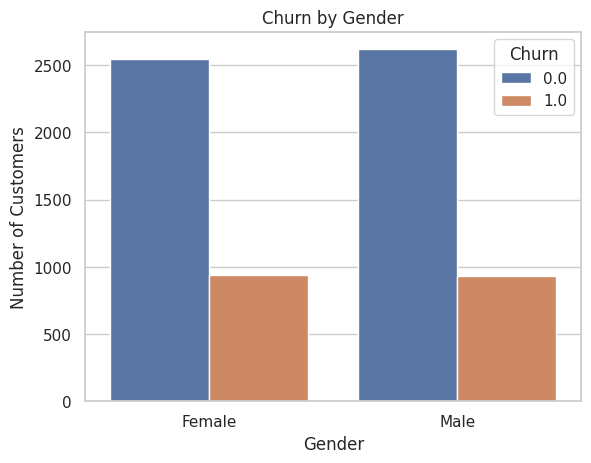

In [39]:
sns.countplot(x='gender', hue='Churn', data=df)

plt.title('Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.show()

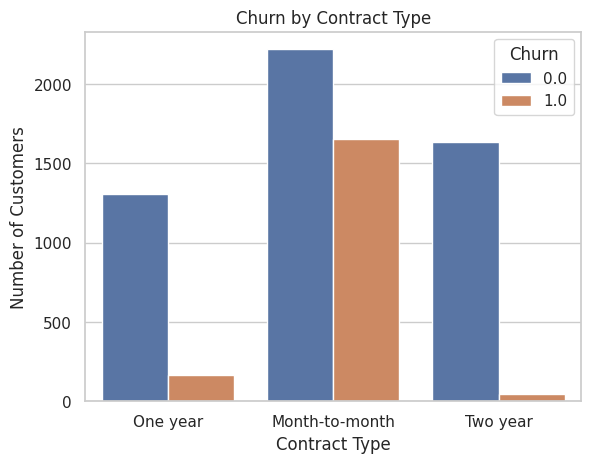

In [40]:
sns.countplot(x='Contract', hue='Churn', data=df)

plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

plt.show()

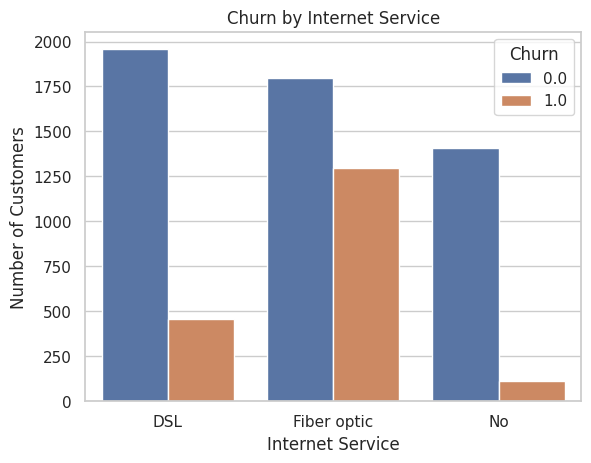

In [41]:
sns.countplot(x='InternetService', hue='Churn', data=df)

plt.title('Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')

plt.show()

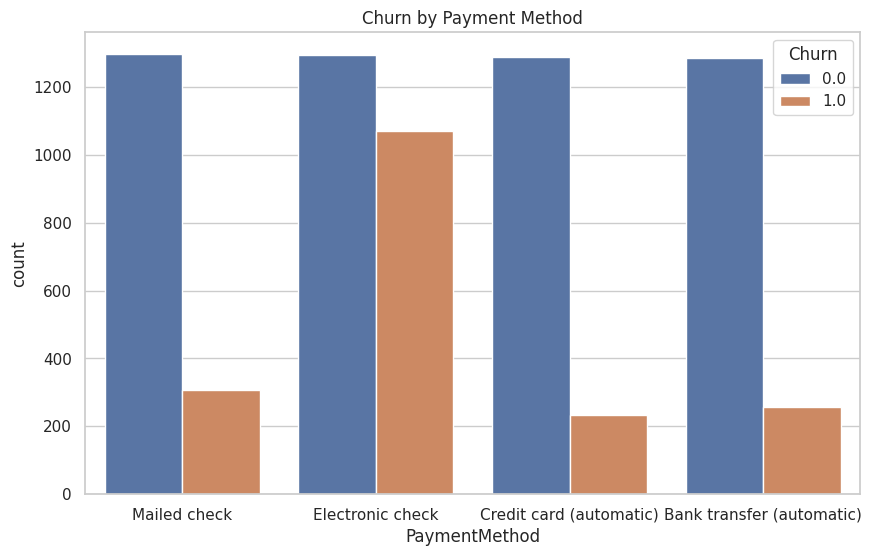

In [42]:
plt.figure(figsize=(10,6))

sns.countplot(x='PaymentMethod', hue='Churn', data=df)

plt.title('Churn by Payment Method')

plt.show()

### Insights

From the categorical analysis, several patterns can be observed:

- Customers with **month-to-month contracts** show higher churn rates.
- Long-term contracts (one or two years) appear to retain customers more effectively.
- Certain payment methods may be associated with higher churn rates.
- Gender does not appear to significantly affect churn behavior.

## Churn Analysis by Numerical Variables

In this step, we analyze how numerical variables such as customer tenure, monthly charges, and total charges differ between customers who churned and those who remained.

By comparing these distributions, we can identify patterns that may explain customer churn behavior.

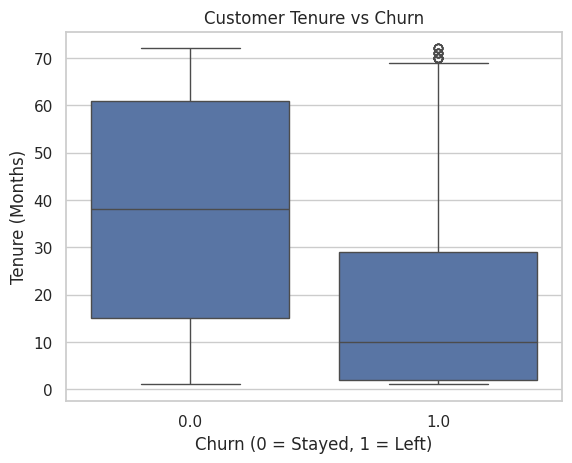

In [43]:
sns.boxplot(x='Churn', y='tenure', data=df)

plt.title('Customer Tenure vs Churn')
plt.xlabel('Churn (0 = Stayed, 1 = Left)')
plt.ylabel('Tenure (Months)')

plt.show()

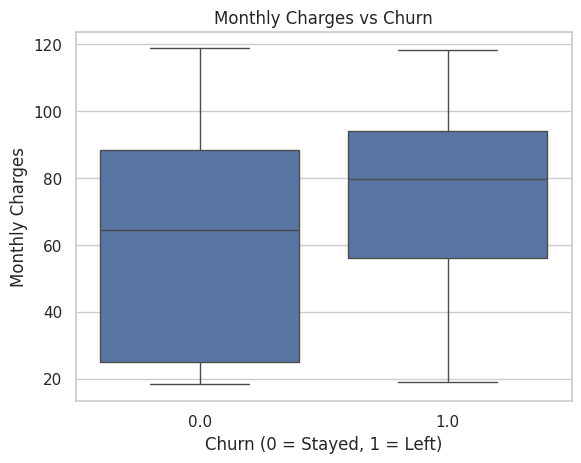

In [44]:
sns.boxplot(x='Churn', y='Charges_Monthly', data=df)

plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn (0 = Stayed, 1 = Left)')
plt.ylabel('Monthly Charges')

plt.show()

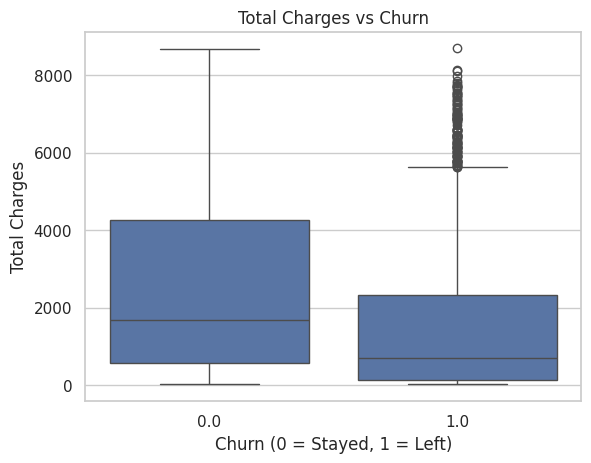

In [45]:
sns.boxplot(x='Churn', y='Charges_Total', data=df)

plt.title('Total Charges vs Churn')
plt.xlabel('Churn (0 = Stayed, 1 = Left)')
plt.ylabel('Total Charges')

plt.show()

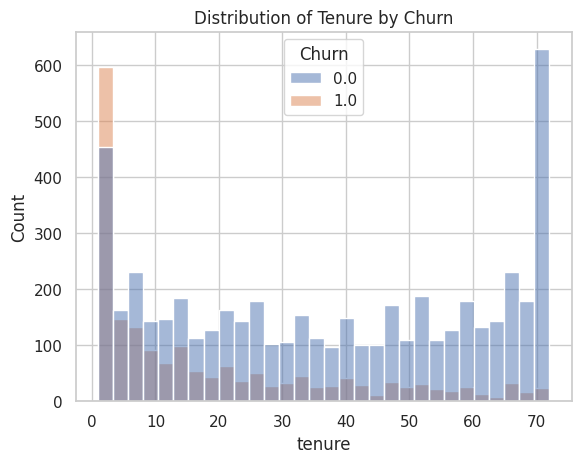

In [46]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30)

plt.title('Distribution of Tenure by Churn')
plt.show()

In [47]:
df.groupby('Churn')[['tenure','Charges_Monthly','Charges_Total']].mean()

,tenure,Charges_Monthly,Charges_Total
Churn,,,
0.0,37.650010,61.307408,2555.344141
1.0,17.979133,74.441332,1531.796094


#📄Informe final

## Telecom X - Churn Analysis Report

**Introduction:**  
This analysis aims to understand the factors related to customer churn in Telecom X. Churn occurs when customers cancel their services, which can negatively affect the company's revenue. The objective of this project is to explore the dataset and identify patterns that may explain why customers leave the service.

**Data Cleaning and Preparation:**  
The dataset was imported from a JSON API and converted into a pandas DataFrame. Nested structures were normalized to obtain a flat dataset. Missing values were checked and corrected, data types were adjusted for numerical variables, and a new column called **Cuentas_Diarias** was created based on monthly charges. Some categorical variables were also standardized to ensure consistency.

**Exploratory Data Analysis:**  
Several visualizations were created to analyze churn distribution and customer behavior. The analysis included examining churn proportions, analyzing categorical variables such as gender, contract type, internet service, and payment method, as well as numerical variables like tenure, monthly charges, and total charges.

**Conclusions and Insights:**  
The analysis shows that customers with **month-to-month contracts** and **shorter tenure** tend to have higher churn rates. Additionally, customers with higher monthly charges appear to have a slightly higher probability of canceling their service.

**Recommendations:**  
Telecom X could reduce churn by encouraging long-term contracts, improving the onboarding experience for new customers, and monitoring customers with higher monthly charges. These strategies may help improve customer retention and reduce service cancellations.

In [48]:

df.to_csv("datos_tratados.csv", index=False)

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

## **Predictive Modeling for Customer Churn**

In this stage, machine learning models are developed to predict customer churn.

The goal is to identify customers who are more likely to cancel their services so that Telecom X can implement proactive retention strategies.

## Removing Irrelevant Columns

Columns that do not contribute to the predictive model are removed.

Identifiers such as `customerID` are unique for each customer and do not provide useful information for predicting churn. Removing them helps improve model performance and avoids unnecessary noise in the dataset.

In [49]:
df = df.drop('customerID', axis=1)
df.columns

Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'Charges_Monthly', 'Charges_Total', 'Cuentas_Diarias'],
      dtype='object')

## Encoding Categorical Variables

Machine learning algorithms require numerical input. Therefore, categorical variables such as contract type, internet service, and payment method must be converted into numeric format.

In this step, we apply **One-Hot Encoding**, which creates binary columns representing each category. This allows the model to process categorical information effectively.

In [51]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [52]:
df_encoded.head(3)

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges_Monthly,Charges_Total,Cuentas_Diarias,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,0,1,1,9,1,1,65.6,593.30,2.19,...,True,False,True,False,False,True,False,False,False,True
1,0.0,0,0,0,9,1,0,59.9,542.40,2.00,...,False,False,False,False,True,False,False,False,False,True
2,1.0,0,0,0,4,1,1,73.9,280.85,2.46,...,False,False,False,False,False,False,False,False,True,False


In [53]:
df_encoded.shape

(7256, 32)

In [59]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Churn                                  7032 non-null   float64
 1   SeniorCitizen                          7256 non-null   int64  
 2   Partner                                7256 non-null   int64  
 3   Dependents                             7256 non-null   int64  
 4   tenure                                 7256 non-null   int64  
 5   PhoneService                           7256 non-null   int64  
 6   PaperlessBilling                       7256 non-null   int64  
 7   Charges_Monthly                        7256 non-null   float64
 8   Charges_Total                          7256 non-null   float64
 9   Cuentas_Diarias                        7256 non-null   float64
 10  gender_Male                            7256 non-null   bool   
 11  MultipleL

In [60]:
df['Churn'].unique()

array([0., 1.])

In [61]:
df = df.dropna(subset=['Churn'])

In [62]:
df['Churn'].isnull().sum()

np.int64(0)

In [63]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [64]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Churn                                  7032 non-null   float64
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   Charges_Monthly                        7032 non-null   float64
 8   Charges_Total                          7032 non-null   float64
 9   Cuentas_Diarias                        7032 non-null   float64
 10  gender_Male                            7032 non-null   bool   
 11  MultipleL

In [66]:
df_encoded['Churn'] = df_encoded['Churn'].astype(int)
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Churn                                  7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   Charges_Monthly                        7032 non-null   float64
 8   Charges_Total                          7032 non-null   float64
 9   Cuentas_Diarias                        7032 non-null   float64
 10  gender_Male                            7032 non-null   bool   
 11  MultipleL

In [67]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

## Class Distribution Analysis

Before training predictive models, it is important to analyze the distribution of the target variable (Churn).

This helps determine whether the dataset is balanced or imbalanced. An imbalance between classes can affect model performance and bias predictions toward the majority class.

In [68]:
df_encoded['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


In [69]:
df_encoded['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
0,73.421502
1,26.578498


/tmp/ipykernel_185/4004445999.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn',data=df_encoded,palette=['#2ECC71','#E74C3C'])


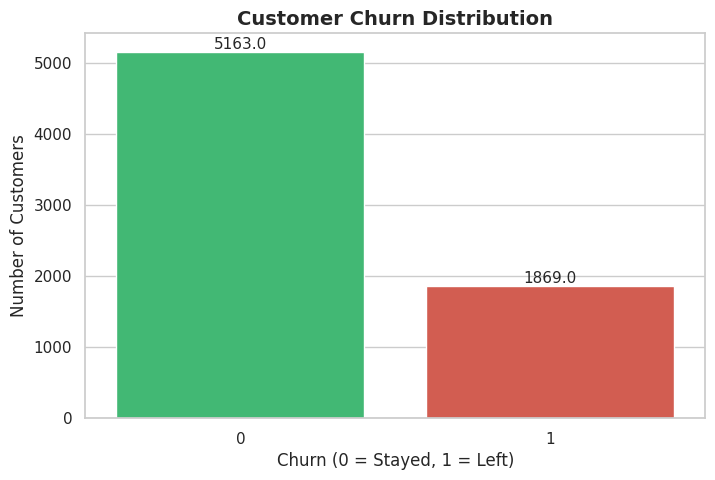

In [77]:
plt.figure(figsize=(8,5))

ax = sns.countplot(x='Churn',data=df_encoded,palette=['#2ECC71','#E74C3C'])

plt.title("Customer Churn Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Churn (0 = Stayed, 1 = Left)")
plt.ylabel("Number of Customers")

# agregar etiquetas
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
    (p.get_x() + p.get_width()/2, p.get_height()),
    ha='center',va='bottom',fontsize=11)

plt.show()

## Handling Class Imbalance

Although the dataset does not show extreme imbalance, techniques such as oversampling can help improve model performance when predicting the minority class.

In this step, the SMOTE (Synthetic Minority Over-sampling Technique) method is applied to generate synthetic samples of the minority class (churn) in order to balance the dataset.

In [78]:
from imblearn.over_sampling import SMOTE

In [79]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [80]:
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

In [81]:
y_resampled.value_counts()

,count
Churn,
0,5163
1,5163


## Data Scaling

Some machine learning algorithms are sensitive to the scale of the data.

Models such as Logistic Regression, KNN, SVM, and Neural Networks rely on distance calculations and therefore require feature scaling. For these models, we apply standardization using **StandardScaler**, which transforms the data so that features have a mean of 0 and a standard deviation of 1.

Tree-based models such as Decision Trees, Random Forest, and XGBoost are not affected by feature scaling, so normalization is not required for those algorithms.

In [83]:
from sklearn.preprocessing import StandardScaler

In [100]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [85]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [86]:
X_train_scaled.shape

(4922, 31)

## Correlation Analysis

To better understand the relationships between variables, we analyze the correlation matrix of the dataset.

This helps identify which numerical variables are most strongly associated with customer churn. Variables with higher correlation values may be important predictors in the machine learning models.

In [87]:
correlation_matrix = df_encoded.corr()

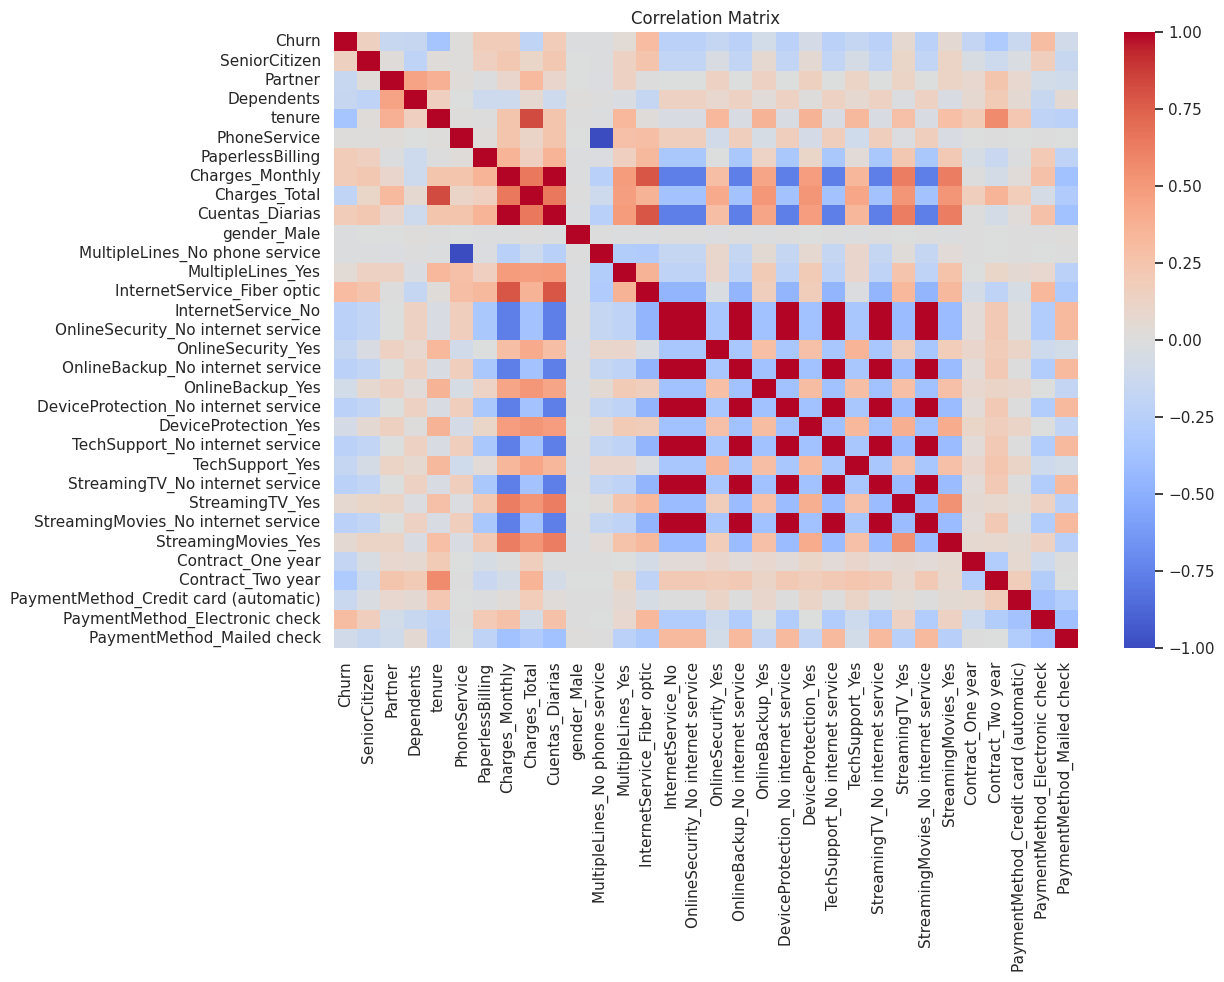

In [88]:
plt.figure(figsize=(12,8))

sns.heatmap(correlation_matrix,cmap='coolwarm',annot=False)

plt.title("Correlation Matrix")
plt.show()

In [89]:
correlation_matrix['Churn'].sort_values(ascending=False)

,Churn
Churn,1.000000
InternetService_Fiber optic,0.307463
PaymentMethod_Electronic check,0.301455
Cuentas_Diarias,0.192914
Charges_Monthly,0.192858
PaperlessBilling,0.191454
SeniorCitizen,0.150541
StreamingTV_Yes,0.063254
StreamingMovies_Yes,0.060860
MultipleLines_Yes,0.040033


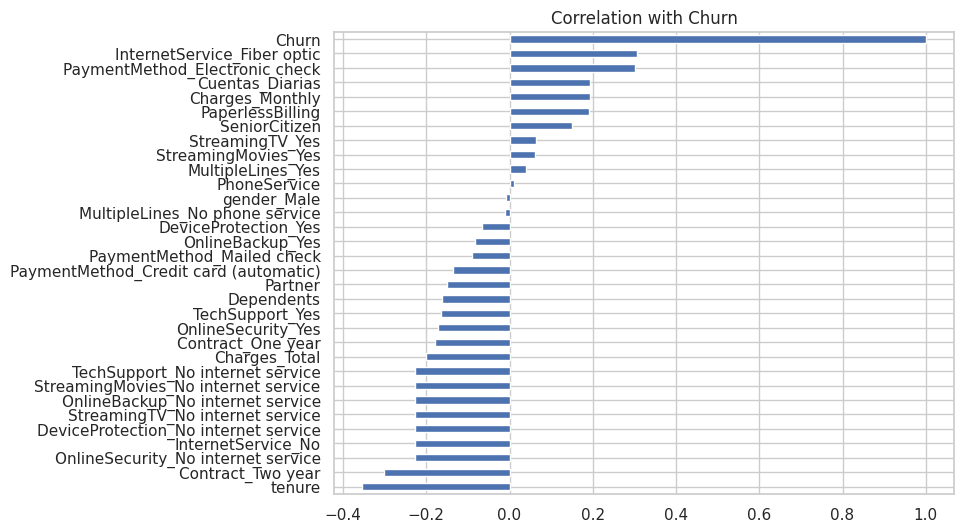

In [90]:
plt.figure(figsize=(8,6))

correlation_matrix['Churn'].sort_values().plot(kind='barh')

plt.title("Correlation with Churn")

plt.show()

## Relationship Between Numerical Variables and Churn

In this step, we explore how certain numerical variables relate to customer churn.

We analyze variables such as contract duration (tenure) and total spending to understand whether customers who cancel their services show different patterns compared to those who remain.

Boxplots and scatter plots help visualize these differences and reveal possible trends.

/tmp/ipykernel_185/1692951224.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


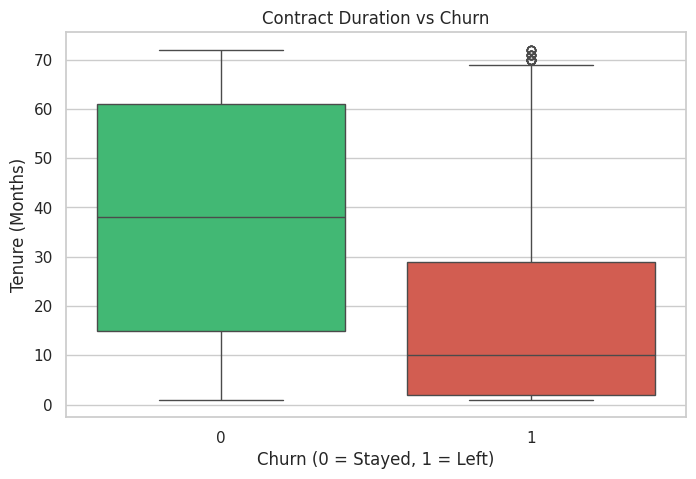

In [92]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='tenure',
    data=df_encoded,
    palette=['#2ECC71','#E74C3C']
)

plt.title("Contract Duration vs Churn")
plt.xlabel("Churn (0 = Stayed, 1 = Left)")
plt.ylabel("Tenure (Months)")

plt.show()

/tmp/ipykernel_185/1015187981.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn',y='Charges_Total',data=df_encoded,palette=['#2ECC71','#E74C3C'])


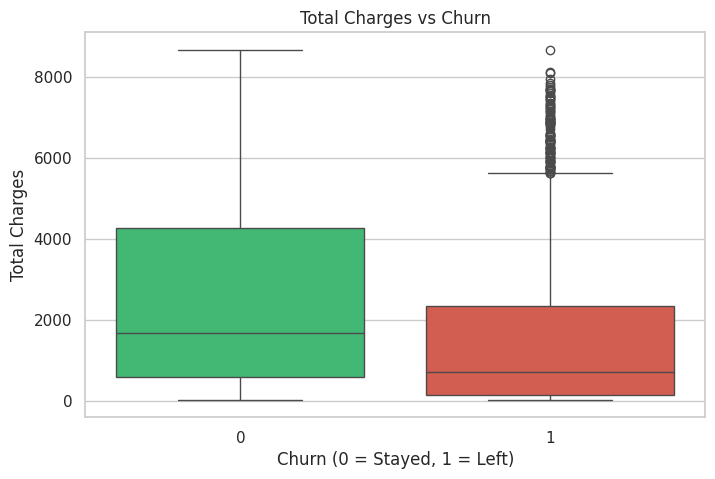

In [94]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn',y='Charges_Total',data=df_encoded,palette=['#2ECC71','#E74C3C'])

plt.title("Total Charges vs Churn")
plt.xlabel("Churn (0 = Stayed, 1 = Left)")
plt.ylabel("Total Charges")

plt.show()

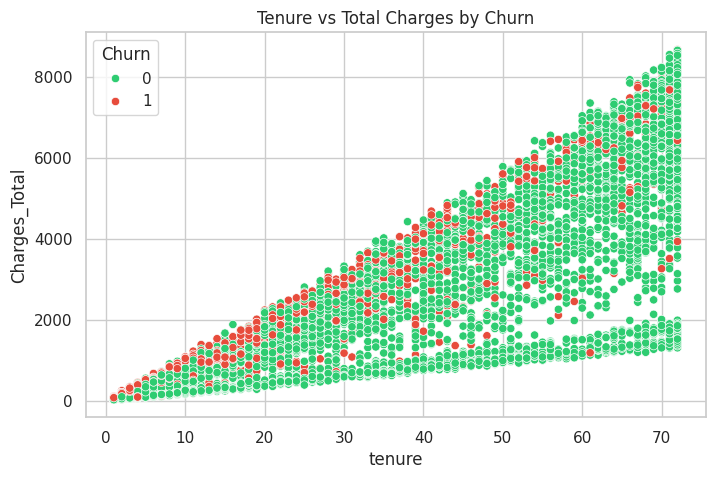

In [95]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='tenure',y='Charges_Total',hue='Churn',data=df_encoded,palette=['#2ECC71','#E74C3C'])
plt.title("Tenure vs Total Charges by Churn")

plt.show()

## Train-Test Split

To properly evaluate the performance of the predictive models, the dataset is divided into training and testing sets.

The training set is used to train the machine learning models, while the testing set is used to evaluate how well the models perform on unseen data.

In this project, a **70/30 split** is applied, meaning that 70% of the data is used for training and 30% for testing.

In [96]:
from sklearn.model_selection import train_test_split

In [101]:
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (4922, 31)
Test set size: (2110, 31)


In [102]:
y_train.value_counts(normalize=True)

,proportion
Churn,
0,0.733239
1,0.266761


In [103]:
y_test.value_counts(normalize=True)

,proportion
Churn,
0,0.736493
1,0.263507


## Predictive Models

Two different machine learning models were implemented to predict customer churn.

- **Logistic Regression:** This model is sensitive to the scale of the data, so feature standardization was applied using StandardScaler.
- **Decision Tree:** This model is based on hierarchical splits and is not affected by the scale of the variables, so normalization was not required.

This approach allows us to compare the performance of models that require scaling with those that do not.

In [104]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [105]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [106]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [107]:
y_pred_log = log_model.predict(X_test_scaled)

In [108]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.8028436018957346
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1554
           1       0.64      0.57      0.60       556

    accuracy                           0.80      2110
   macro avg       0.75      0.73      0.74      2110
weighted avg       0.80      0.80      0.80      2110



In [110]:
from sklearn.tree import DecisionTreeClassifier

In [111]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [112]:
y_pred_tree = tree_model.predict(X_test)

In [113]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.7241706161137441
              precision    recall  f1-score   support

           0       0.83      0.79      0.81      1554
           1       0.48      0.53      0.50       556

    accuracy                           0.72      2110
   macro avg       0.65      0.66      0.66      2110
weighted avg       0.73      0.72      0.73      2110



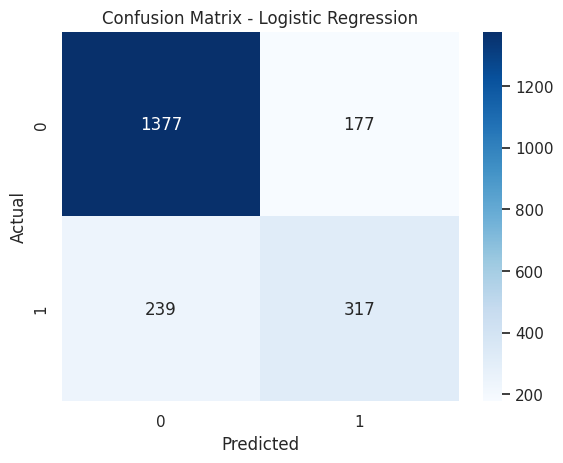

In [114]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Model Evaluation

To evaluate the performance of the predictive models, several classification metrics are used:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

These metrics help determine how well the models predict customer churn and allow comparison between different algorithms.

In [115]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

print("\nClassification Report - Logistic Regression")
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.8028436018957346

Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1554
           1       0.64      0.57      0.60       556

    accuracy                           0.80      2110
   macro avg       0.75      0.73      0.74      2110
weighted avg       0.80      0.80      0.80      2110



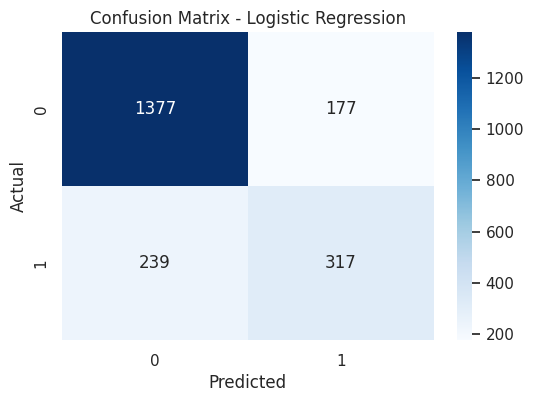

In [116]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [117]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))

print("\nClassification Report - Decision Tree")
print(classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.7241706161137441

Classification Report - Decision Tree
              precision    recall  f1-score   support

           0       0.83      0.79      0.81      1554
           1       0.48      0.53      0.50       556

    accuracy                           0.72      2110
   macro avg       0.65      0.66      0.66      2110
weighted avg       0.73      0.72      0.73      2110



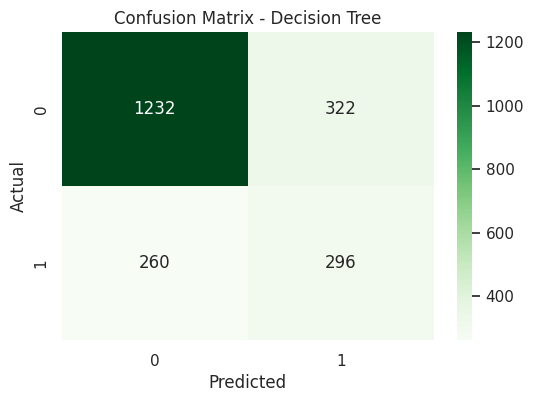

In [118]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6,4))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens')

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [119]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [accuracy_score(y_test, y_pred_log),accuracy_score(y_test, y_pred_tree)]})

results

,Model,Accuracy
0,Logistic Regression,0.802844
1,Decision Tree,0.724171


## Feature Importance Analysis

After training the predictive models, it is important to analyze which variables have the greatest influence on customer churn.

Understanding feature importance helps identify the factors that most strongly affect the probability of cancellation and provides valuable insights for strategic decision-making.

In [120]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

coefficients.head(10)

,Feature,Coefficient
7,Charges_Total,0.944853
12,InternetService_Fiber optic,0.652327
23,StreamingTV_Yes,0.209234
25,StreamingMovies_Yes,0.191190
11,MultipleLines_Yes,0.188667
29,PaymentMethod_Electronic check,0.176110
5,PaperlessBilling,0.171394
0,SeniorCitizen,0.093451
19,DeviceProtection_Yes,0.049636
10,MultipleLines_No phone service,0.041543


In [121]:
coefficients.sort_values(by="Coefficient").head(10)

,Feature,Coefficient
3,tenure,-1.632741
27,Contract_Two year,-0.663747
6,Charges_Monthly,-0.416026
8,Cuentas_Diarias,-0.330166
26,Contract_One year,-0.301277
15,OnlineSecurity_Yes,-0.125363
21,TechSupport_Yes,-0.122048
2,Dependents,-0.102528
13,InternetService_No,-0.080559
24,StreamingMovies_No internet service,-0.080559


/tmp/ipykernel_185/1232789234.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Coefficient",y="Feature",data=top_features,palette="viridis")


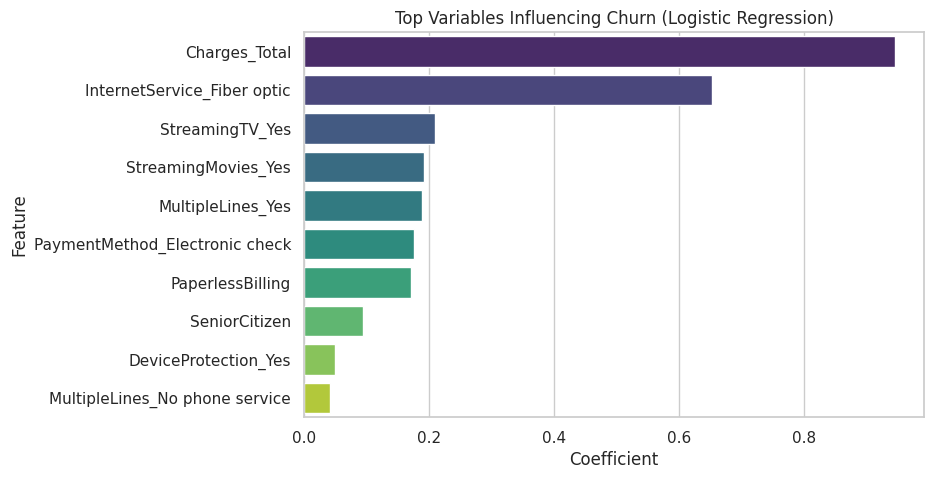

In [122]:
top_features = coefficients.head(10)

plt.figure(figsize=(8,5))

sns.barplot(x="Coefficient",y="Feature",data=top_features,palette="viridis")
plt.title("Top Variables Influencing Churn (Logistic Regression)")

plt.show()

In [123]:
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree_model.feature_importances_
})

importances = importances.sort_values(by="Importance", ascending=False)

importances.head(10)

,Feature,Importance
3,tenure,0.207527
7,Charges_Total,0.199758
6,Charges_Monthly,0.116058
12,InternetService_Fiber optic,0.106247
8,Cuentas_Diarias,0.077719
9,gender_Male,0.025309
17,OnlineBackup_Yes,0.024128
27,Contract_Two year,0.021920
1,Partner,0.019563
15,OnlineSecurity_Yes,0.019245


/tmp/ipykernel_185/2685406761.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


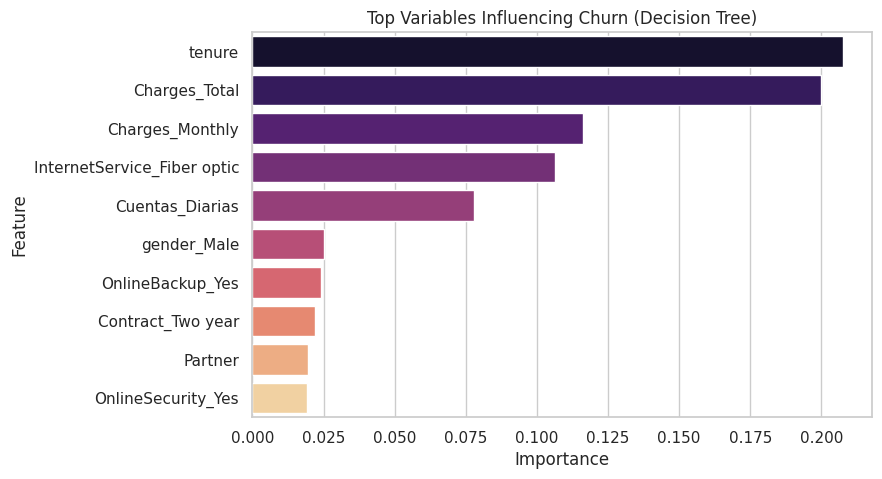

In [124]:
top_tree_features = importances.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_tree_features,
    palette="magma"
)

plt.title("Top Variables Influencing Churn (Decision Tree)")

plt.show()

## Key Factors Influencing Churn

The feature importance analysis reveals several key variables that influence customer churn.

Variables such as **contract type, tenure, and monthly charges** play an important role in predicting whether a customer will cancel their service.

Customers with short-term contracts and shorter tenure tend to have a higher probability of churn, while long-term contracts are associated with greater customer retention.

Understanding these factors can help Telecom X design targeted strategies to reduce churn and improve customer satisfaction.

## Final Report: Customer Churn Analysis

### Objective
The objective of this project was to analyze customer churn at Telecom X and build predictive models capable of identifying customers who are more likely to cancel their services. Understanding the factors behind churn can help the company implement better retention strategies.

### Data Preparation
The dataset was cleaned and prepared for machine learning. The main steps included removing irrelevant variables such as customer IDs, converting categorical variables into numerical format using one-hot encoding, and splitting the dataset into training and testing sets. Feature scaling was applied when required by the selected models.

### Models Implemented
Two classification models were used to predict churn:

- **Logistic Regression**, which requires normalized data and allows interpretation of variable coefficients.
- **Decision Tree**, which does not require normalization and can capture nonlinear relationships.

Both models were evaluated using metrics such as **accuracy, precision, recall, F1-score, and confusion matrix**.

### Key Factors Influencing Churn
The analysis revealed that the most relevant variables influencing customer churn include:

- **Contract type**
- **Customer tenure**
- **Monthly charges**
- **Total charges**

Customers with **month-to-month contracts**, **shorter tenure**, and **higher monthly charges** showed a higher probability of canceling their services.

### Strategic Insights
The results suggest that churn is strongly related to early stages of the customer lifecycle and contract flexibility. Customers who recently joined the company and are on short-term contracts represent the highest churn risk.

### Recommendations
Based on the analysis, Telecom X could reduce churn by:

- Encouraging customers to switch to **long-term contracts** through incentives.
- Improving the **onboarding experience** for new customers.
- Monitoring customers with **higher monthly charges**.
- Implementing a **predictive churn monitoring system** to identify high-risk customers early.

These strategies can help Telecom X improve customer retention and reduce service cancellations.